In [1]:
!git clone "https://github.com/schiWasTaken/YOLOv5-PyTorch.git"
%cd "YOLOv5-PyTorch"
!git checkout schi1

Cloning into 'YOLOv5-PyTorch'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 312 (delta 73), reused 52 (delta 51), pack-reused 188 (from 2)
Receiving objects: 100% (312/312), 87.22 MiB | 17.08 MiB/s, done.
Resolving deltas: 100% (144/144), done.
/content/YOLOv5-PyTorch
Branch 'schi1' set up to track remote branch 'schi1' from 'origin'.
Switched to a new branch 'schi1'


In [2]:
import os

file_id = "1ZQt1vACHTN98QJYaT2JW3kPF-wziHyPX"
os.makedirs("ckpts", exist_ok=True)
output = "ckpts/model_best.pth.tar"

!gdown --id {file_id} -O {output}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ZQt1vACHTN98QJYaT2JW3kPF-wziHyPX
To: /content/YOLOv5-PyTorch/ckpts/model_best.pth.tar
100% 45.3M/45.3M [00:00<00:00, 209MB/s]


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="M8g3XQqHBOnUeEIk4eih")
project = rf.workspace("kuliah-rwptj").project("traffic-sign-indonesia")
version = project.version(2)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 130.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Sign-Indonesia-2 in coco:: 100%|██████████| 3530/3530 [00:00<00:00, 5218.20it/s]


In [4]:
import torch
import yolo
from PIL import Image
from torchvision import transforms

classes = (
  "Dilarang Berhenti",
  "Dilarang Masuk",
  "Dilarang Parkir",
  "Lampu Hijau",
  "Lampu Kuning",
  "Lampu Merah",
  "Larangan Belok Kanan",
  "Larangan Belok Kiri",
  "Larangan Berjalan Terus Wajib Berhenti Sesaat",
  "Larangan Memutar Balik",
  "Peringatan Alat Pemberi Isyarat Lalu Lintas",
  "Peringatan Banyak Pejalan Kaki Menggunakan Zebra Cross",
  "Peringatan Hati-Hati",
  "Peringatan Pintu Perlintasan Kereta Api",
  "Peringatan Simpang Tiga Sisi Kiri",
  "Perintah Masuk Jalur Kiri",
  "Perintah Pilihan Memasuki Salah Satu Jalur",
  "Petunjuk Area Parkir",
  "Petunjuk Lokasi Pemberhentian Bus",
  "Petunjuk Lokasi Putar Balik",
  "Petunjuk Penyeberangan Pejalan Kaki")

model = yolo.YOLOv5(22, img_sizes=(640, 640), score_thresh=0.25)
model.eval()

YOLOv5(
  (backbone): BackboneWithFPN(
    (body): MyAwesomeLayers(
      (stem): Sequential(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): InvertedResidual(
          (conv): Sequential(
            (0): ConvNormAct(
              (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (norm_layer): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (1): ConvNormAct(
              (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (norm_layer): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (act): SiLU()
            )
            (2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (stage1): Sequential(
      

In [5]:
import os
import shutil

# 🧠 Change this variable if your dataset folder name changes
dataset_name = "Traffic-Sign-Indonesia-2"
base_dir = f"/content/YOLOv5-PyTorch/{dataset_name}"

# Paths
train_old = os.path.join(base_dir, "train")
val_old = os.path.join(base_dir, "valid")
train_new = os.path.join(base_dir, "train2017")
val_new = os.path.join(base_dir, "val2017")
annotations_dir = os.path.join(base_dir, "annotations")

# --- Rename train/val folders ---
if os.path.exists(train_old):
    os.rename(train_old, train_new)
    print(f"📁 Renamed: {train_old} → {train_new}")
else:
    print(f"⚠️ Skipped: {train_old} not found")

if os.path.exists(val_old):
    os.rename(val_old, val_new)
    print(f"📁 Renamed: {val_old} → {val_new}")
else:
    print(f"⚠️ Skipped: {val_old} not found")

# --- Create annotations directory ---
os.makedirs(annotations_dir, exist_ok=True)
print(f"📂 Created annotations folder: {annotations_dir}")

# --- Copy and rename JSON files ---
train_json_src = os.path.join(train_new, "_annotations.coco.json")
val_json_src = os.path.join(val_new, "_annotations.coco.json")

train_json_dst = os.path.join(annotations_dir, "instances_train2017.json")
val_json_dst = os.path.join(annotations_dir, "instances_val2017.json")

if os.path.exists(train_json_src):
    shutil.copy2(train_json_src, train_json_dst)
    print(f"✅ Copied: {train_json_src} → {train_json_dst}")
else:
    print(f"⚠️ Missing: {train_json_src}")

if os.path.exists(val_json_src):
    shutil.copy2(val_json_src, val_json_dst)
    print(f"✅ Copied: {val_json_src} → {val_json_dst}")
else:
    print(f"⚠️ Missing: {val_json_src}")

print("\n🎉 All operations completed!")



📁 Renamed: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train → /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017
📁 Renamed: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/valid → /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/val2017
📂 Created annotations folder: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations
✅ Copied: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017/_annotations.coco.json → /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_train2017.json
✅ Copied: /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/val2017/_annotations.coco.json → /content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_val2017.json

🎉 All operations completed!


In [6]:
import os

use_cuda = False
dataset = "coco" # currently only support VOC and COCO datasets
file_root = "Traffic-Sign-Indonesia-2/test"
ann_file = "Traffic-Sign-Indonesia-2/test/_annotations.coco.json"
output_dir = "output_dir"
ckpt_path = "/content/YOLOv5-PyTorch/ckpts/yolov5s_coco-20.pth"

# create output directory
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

# choose device and show GPU information
device = torch.device("cuda" if torch.cuda.is_available() and use_cuda else "cpu")
cuda = device.type == "cuda"
if cuda: yolo.get_gpu_prop(show=True)
print("\ndevice: {}".format(device))

ds = yolo.datasets(dataset, file_root, ann_file, train=True)
dl = torch.utils.data.DataLoader(ds, shuffle=True, collate_fn=yolo.collate_wrapper, pin_memory=cuda)
# DataPrefetcher behaves like PyTorch's DataLoader, but it outputs CUDA tensors
d = yolo.DataPrefetcher(dl) if cuda else dl

model.to(device)

if ckpt_path:
    checkpoint = torch.load(ckpt_path, map_location=device)
    if "ema" in checkpoint:
        model.load_state_dict(checkpoint["ema"][0])
        print(checkpoint["eval_info"])
    else:
        model.load_state_dict(checkpoint)
    del checkpoint
    if cuda: torch.cuda.empty_cache()

for p in model.parameters():
    p.requires_grad_(False)


device: cpu
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Checking the dataset...
checked id file: Traffic-Sign-Indonesia-2/checked_test.txt
147 samples are OK; 0.0 seconds
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.906
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.696
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.250
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.607
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.609
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.636
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.636
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= sm

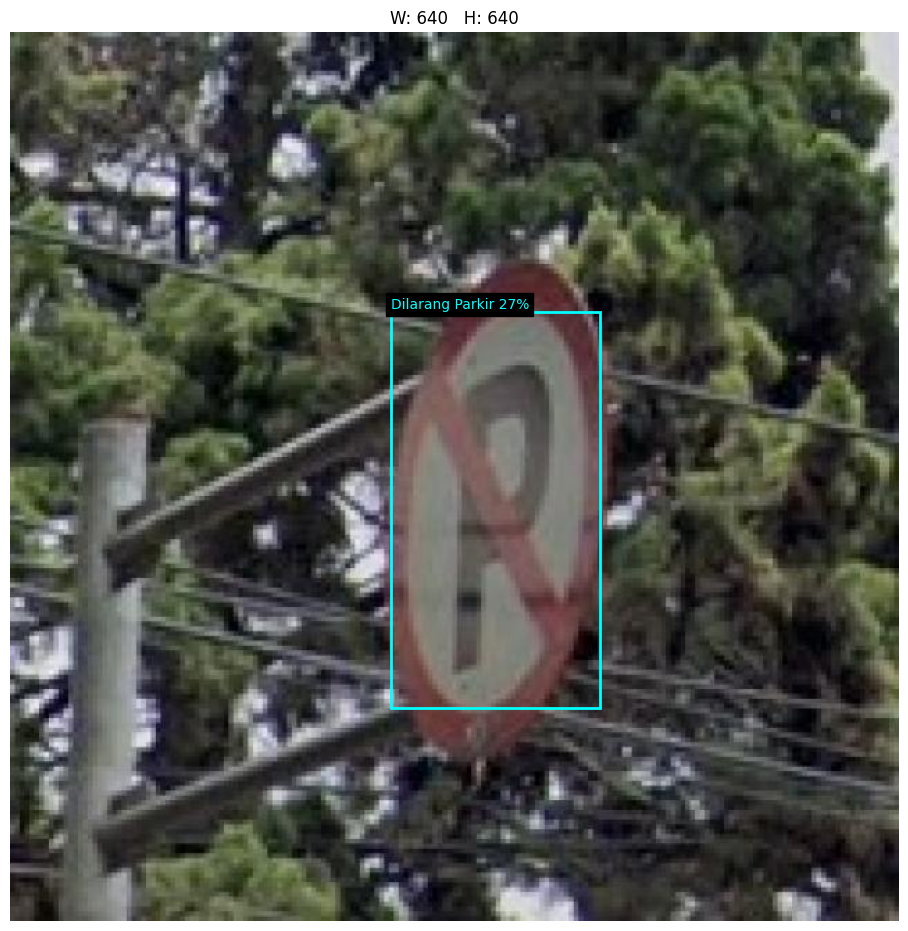

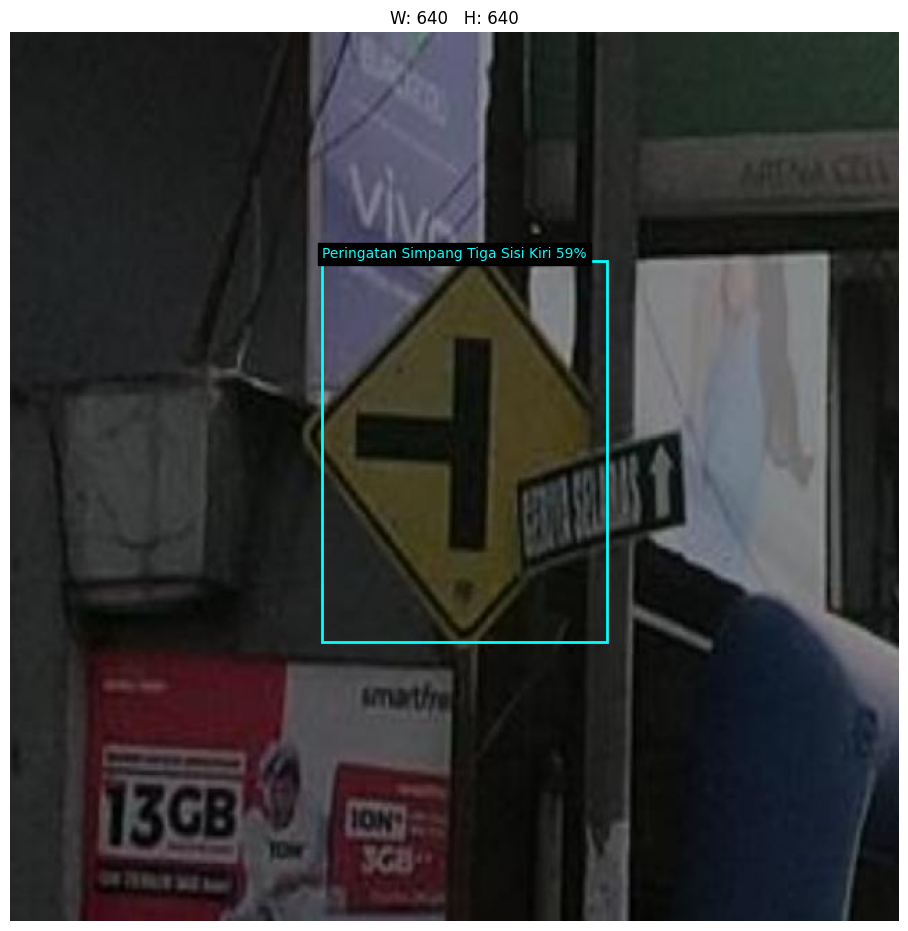

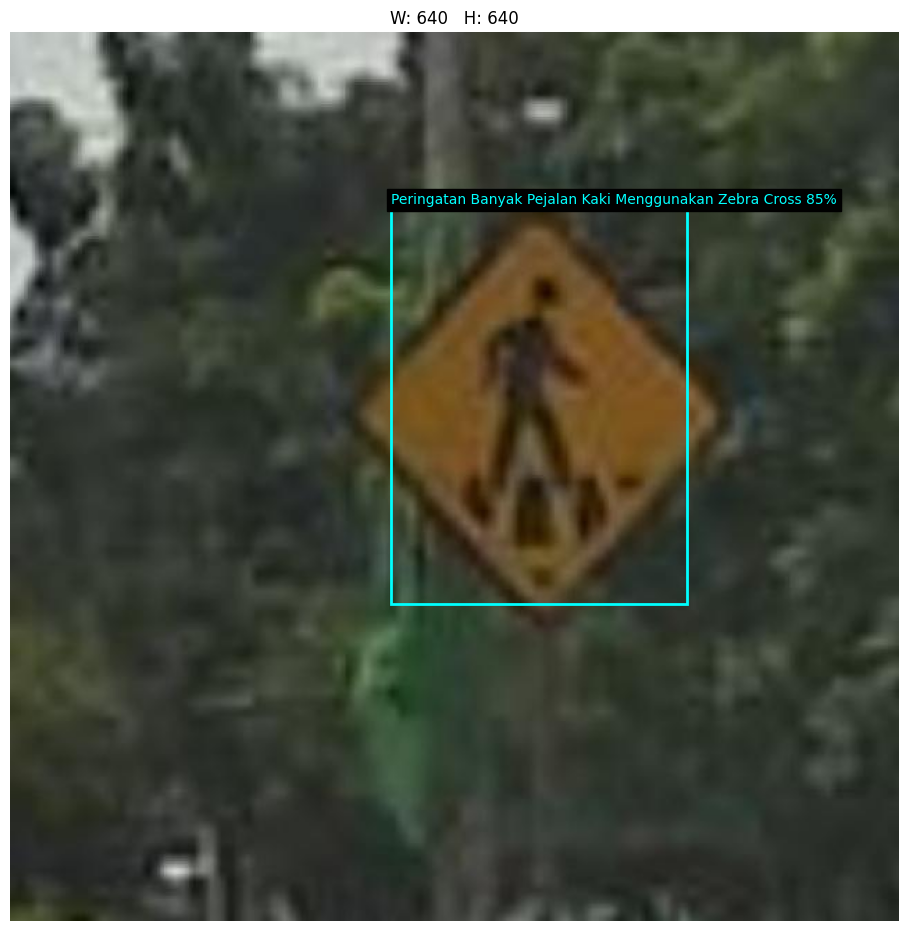

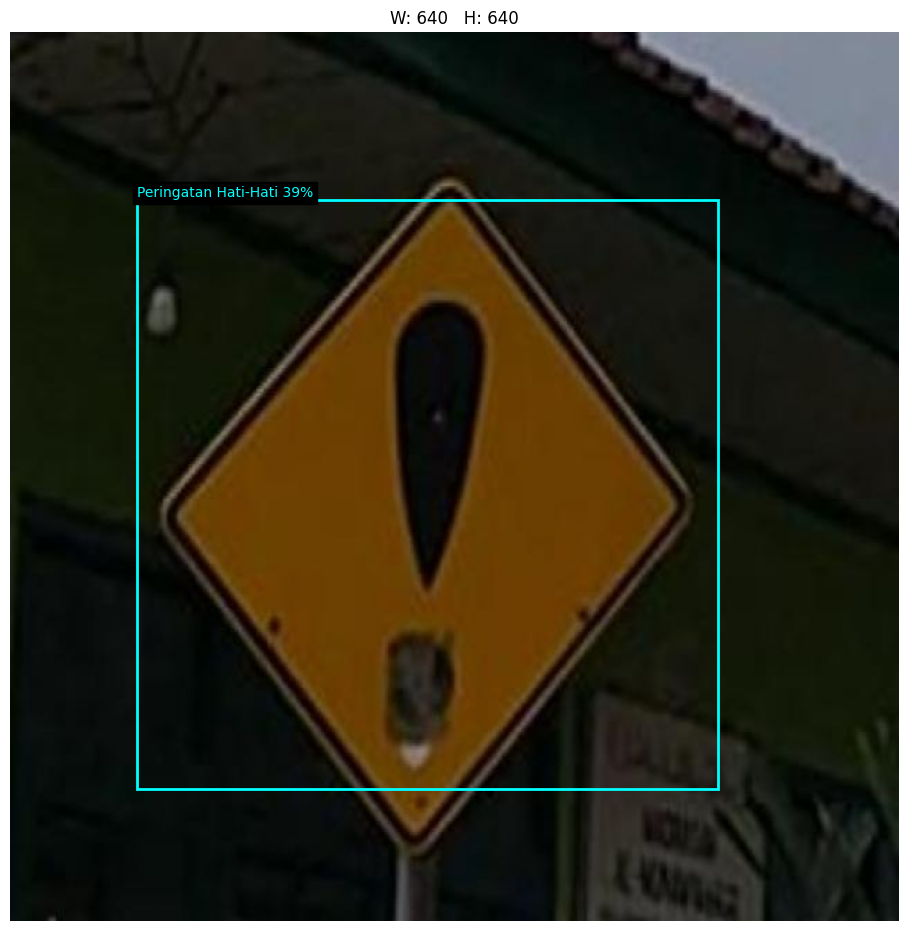

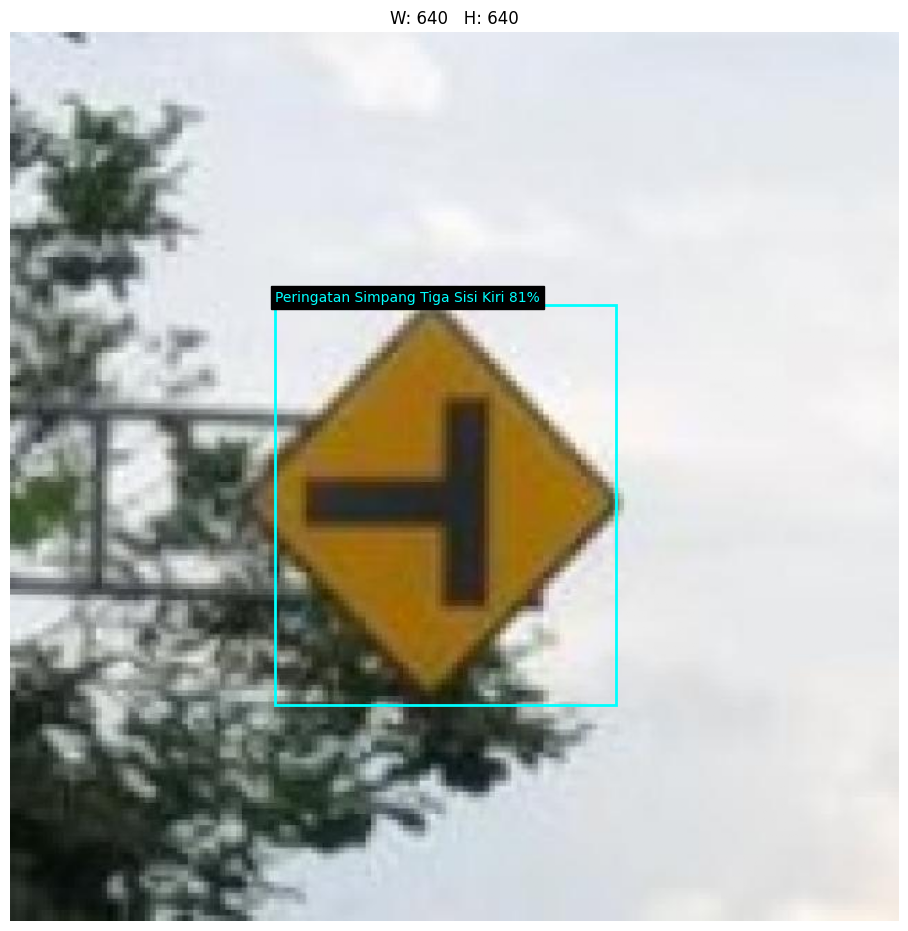

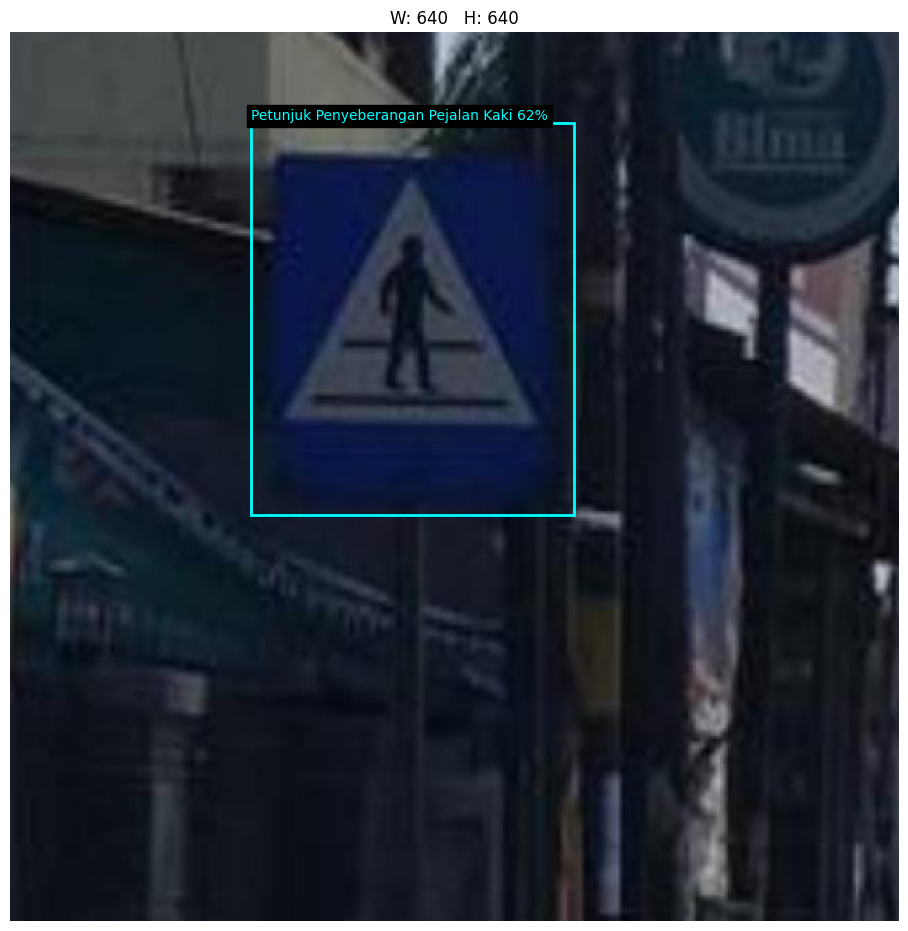

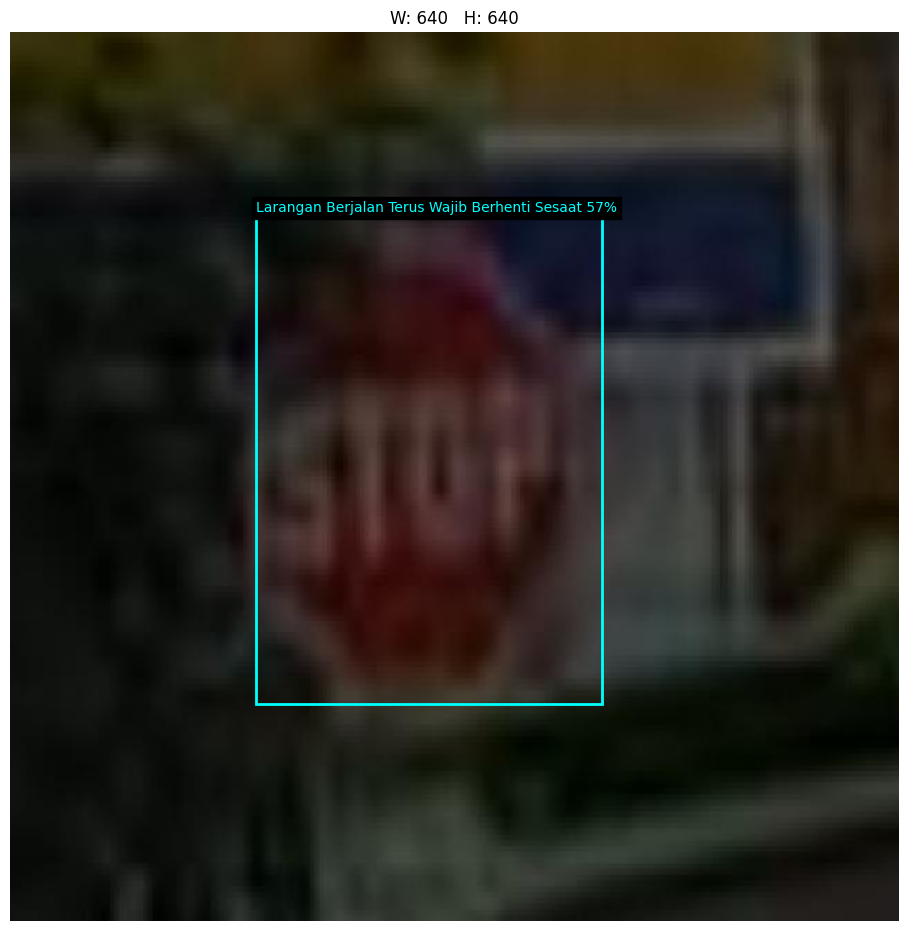

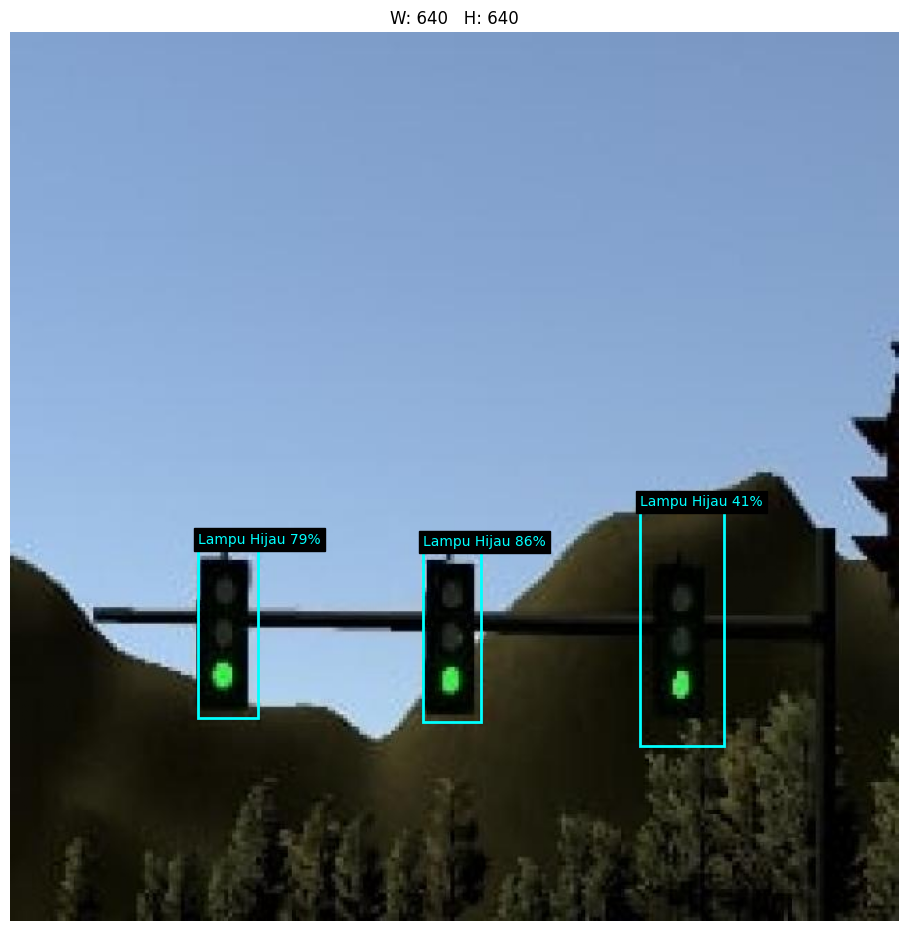

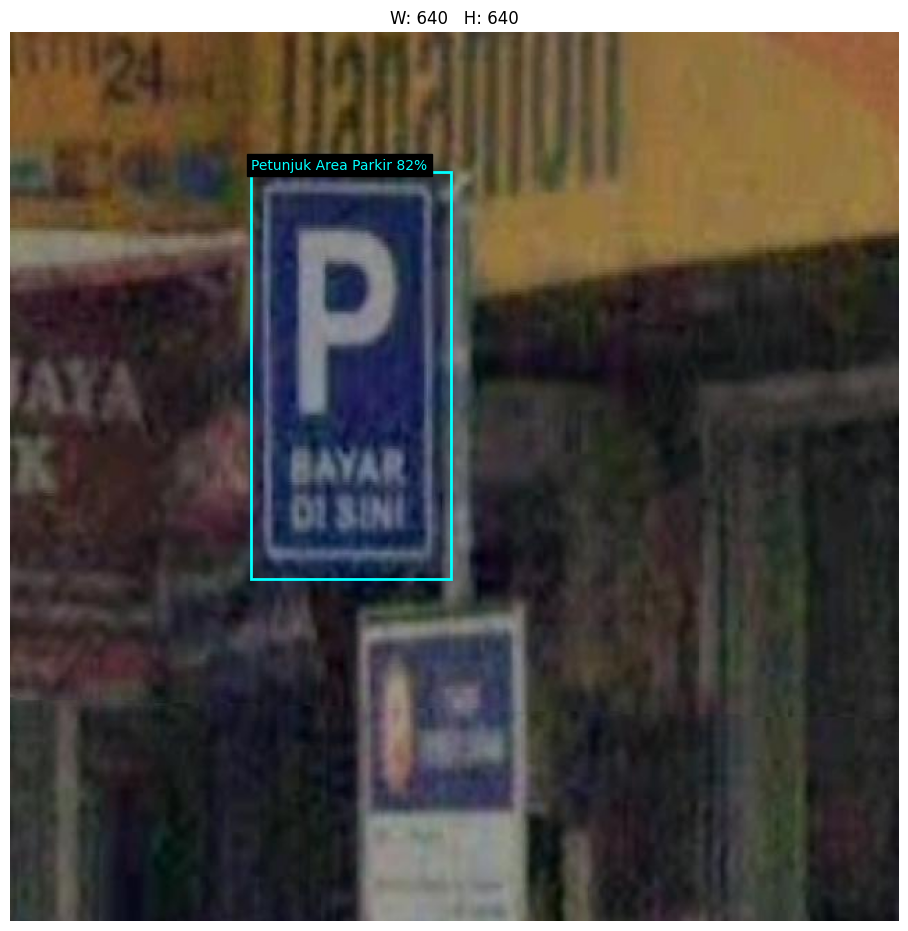

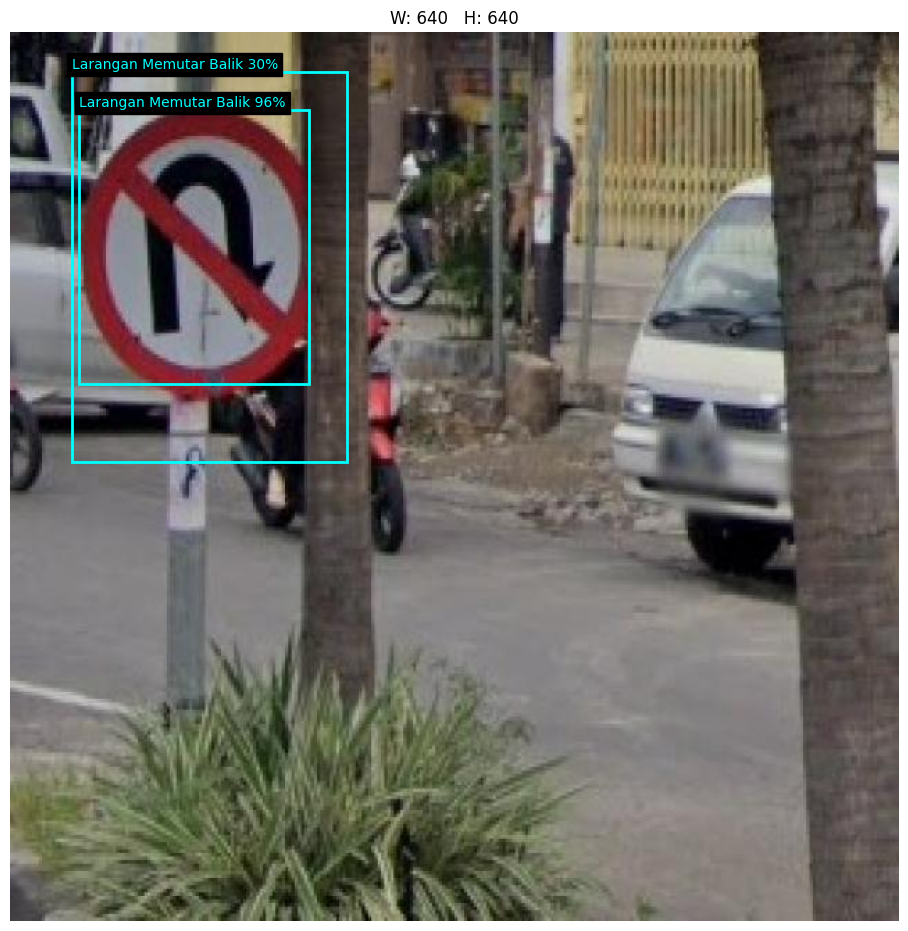

In [7]:
import torch
import torchvision.transforms.functional as F
iters = 10

for i, data in enumerate(d):
    images = data.images
    targets = data.targets

    def preprocess_tensor(img: torch.Tensor):
            # img shape: [C,H,W], dtype float or uint8
            img = F.center_crop(img, [640, 640])   # crop to square
            img = F.resize(img, [640, 640])        # resize to 256x256
            if img.dtype != torch.float32:
                img = img.float() / 255.0          # normalize to [0,1] if needed
            return img

    images = [preprocess_tensor(img) for img in images]
    images = torch.stack(images, dim=0)   # [B,C,256,256]

    with torch.no_grad():
        results, losses = model(images)

    # images' saving names
    save = [os.path.join(output_dir, "{}.jpg".format(tgt["image_id"].item())) for tgt in targets]
    yolo.show(images, results, ds.classes, save)

    if i >= iters - 1:
        break

In [ ]:
# import os
# import json
# from collections import defaultdict
# import shutil

# # === CONFIG ===
# json_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/test/_annotations.coco.json"  # path to your COCO json
# folder = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/test"           # path to your folder with JPGs


# # === LOAD JSON ===
# with open(json_path, "r") as f:
#     data = json.load(f)

# json_files = [img["file_name"] for img in data["images"]]
# json_map = defaultdict(list)
# for name in json_files:
#     prefix = name.split(".rf.")[0]
#     json_map[prefix].append(name)

# folder_files = [f for f in os.listdir(folder) if f.endswith(".jpg")]
# folder_map = defaultdict(list)
# for f in folder_files:
#     prefix = f.split(".rf.")[0]
#     folder_map[prefix].append(f)

# renamed, duplicated, missing = [], [], []

# for prefix, targets in json_map.items():
#     existing = folder_map.get(prefix, [])
#     if not existing:
#         print(f"❌ No source file found for prefix: {prefix}")
#         missing.extend(targets)
#         continue

#     # Pick the first available file as source
#     source_file = os.path.join(folder, existing[0])

#     for i, target in enumerate(targets):
#         target_path = os.path.join(folder, target)

#         # Skip if already correct
#         if os.path.exists(target_path):
#             continue

#         # Reconfirm that the source still exists
#         if not os.path.exists(source_file):
#             # It might have been renamed earlier
#             possible_sources = [os.path.join(folder, t) for t in targets if os.path.exists(os.path.join(folder, t))]
#             if possible_sources:
#                 source_file = possible_sources[0]
#             else:
#                 print(f"⚠️ All sources missing for {prefix}, skipping {target}")
#                 missing.append(target)
#                 continue

#         if os.path.basename(source_file) == os.path.basename(target_path):
#             print(f"⚠️ Skipping same-name copy: {target}")
#             continue

#         if i == 0:
#             print(f"🔁 Renaming: {os.path.basename(source_file)}  →  {target}")
#             os.rename(source_file, target_path)
#             source_file = target_path  # Update source after rename
#             renamed.append((prefix, target))
#         else:
#             print(f"📄 Duplicating: {os.path.basename(source_file)}  →  {target}")
#             shutil.copy2(source_file, target_path)
#             duplicated.append(target)

# print(f"\n✅ Done! Renamed {len(renamed)} | Duplicated {len(duplicated)} | Missing {len(missing)}")


✅ Done! Renamed 0 | Duplicated 0 | Missing 0


In [ ]:
# import os
# import json

# # === CONFIGURATION ===
# folder = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017"         # path to your image folder
# json_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_train2017.json"

# # === LOAD JSON ===
# with open(json_path, "r") as f:
#     data = json.load(f)

# # Get filenames referenced in JSON
# json_files = {img["file_name"] for img in data["images"]}

# # Get all JPG files in folder
# folder_files = [f for f in os.listdir(folder) if f.endswith(".jpg")]

# # Identify extra files not in JSON
# extra_files = [f for f in folder_files if f not in json_files]

# print(f"Total images in JSON: {len(json_files)}")
# print(f"Total images in folder: {len(folder_files)}")
# print(f"⚠️ Missing in JSON (exist in folder but not referenced): {len(extra_files)}")

# for f in extra_files[:20]:
#     print("   ", f)
# if len(extra_files) > 20:
#     print("   ...")

# # === DELETE CONFIRMATION ===
# confirm = input("\nType 'yes' to DELETE these files permanently: ").strip().lower()
# if confirm == "yes":
#     for f in extra_files:
#         os.remove(os.path.join(folder, f))
#     print(f"✅ Deleted {len(extra_files)} unreferenced files.")
# else:
#     print("❌ Deletion cancelled.")


In [ ]:
# import json
# import os

# # === CONFIG ===
# json_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/annotations/instances_train2017.json"
# image_dir = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017"

# # === LOAD JSON ===
# with open(json_path, "r") as f:
#     data = json.load(f)

# # Extract image filenames from JSON
# json_images = {img["file_name"] for img in data["images"]}

# # Extract filenames (without subdirs) from the image folder
# folder_images = {f for f in os.listdir(image_dir) if f.lower().endswith(".jpg")}

# # Compare sets
# missing_in_folder = sorted(list(json_images - folder_images))
# missing_in_json = sorted(list(folder_images - json_images))

# # === REPORT ===
# print(f"Total images in JSON: {len(json_images)}")
# print(f"Total images in folder: {len(folder_images)}\n")

# print(f"❌ Missing in folder (referenced but not found): {len(missing_in_folder)}")
# for name in missing_in_folder[:10]:
#     print("  ", name)
# if len(missing_in_folder) > 10:
#     print("  ...")

# print(f"\n⚠️ Missing in JSON (exist in folder but not referenced): {len(missing_in_json)}")
# for name in missing_in_json[:10]:
#     print("  ", name)
# if len(missing_in_json) > 10:
#     print("  ...")


In [9]:
import train
import os
import sys
import subprocess
import argparse

def mainfunc():
    root = "."
    dataset = "coco"
    batch_size = 4
    print_freq = 100
    lr = 0.01
    epochs = 10
    period = 10
    img_size1, img_size2 = 640, 640
    ckpt_file = f"yolov5s_{dataset}.pth"
    iters = -1

    if dataset == "voc":
        data_dir = os.path.join(root, "input/data/voc2012/VOCdevkit/VOC2012/")
    elif dataset == "coco":
        data_dir = os.path.join(root, "Traffic-Sign-Indonesia-2")

    train_py = os.path.join(root, "train.py")
    args = [
        # sys.executable, train_py,
        "--use-cuda",
        "--epochs", str(epochs),
        "--period", str(period),
        "--batch-size", str(batch_size),
        "--lr", str(lr),
        "--img-sizes", str(img_size1), str(img_size2),
        "--dataset", dataset,
        "--data-dir", data_dir,
        "--iters", str(iters),
        "--root", root,
        "--mosaic",
        "--dali",
        "--ckpt-path", os.path.join(root, "ckpts", ckpt_file),
        "--print-freq", str(print_freq),
    ]

    parser = argparse.ArgumentParser()
    parser.add_argument("--use-cuda", action="store_true") # whether use the GPU

    parser.add_argument("--dataset", default="coco") # style of dataset, choice: ["coco", "voc"]
    parser.add_argument("--data-dir", default="/data/coco2017") # root directory of the dataset
    parser.add_argument("--dali", action="store_true") # NVIDIA's DataLoader, faster but without random affine
    parser.add_argument("--ckpt-path") # basic checkpoint path
    parser.add_argument("--results") # path where to save the evaluation results

    # you may not train the model for 273 epochs once, and want to split it into several tasks.
    # set epochs={the target epoch of each training task}
    parser.add_argument("--epochs", type=int, default=1)

    # total epochs. iterations=500000, true batch size=64, so total epochs=272.93
    parser.add_argument("--period", type=int, default=273)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--iters", type=int, default=-1) # max iterations per epoch, -1 denotes an entire epoch

    parser.add_argument("--seed", type=int, default=3) # random seed
    parser.add_argument("--model-size", default="small") # choice: ["small", "medium", "large", "extreme"]
    parser.add_argument('--img-sizes', nargs="+", type=int, default=[320, 416]) # range of input images' max_size during training
    parser.add_argument("--lr", type=float, default=0.01)
    parser.add_argument("--momentum", type=float, default=0.937)
    parser.add_argument("--weight-decay", type=float, default=0.0005)

    parser.add_argument("--mosaic", action="store_true") # mosaic data augmentaion, increasing ~2% AP, a little slow
    parser.add_argument("--print-freq", type=int, default=100) # frequency of printing losses during training
    parser.add_argument("--world-size", type=int, default=1) # total number of processes
    parser.add_argument("--dist-url", default="env://") # distributed initial method

    parser.add_argument("--root") # gpu cloud platform special
    args = parser.parse_args(args)

    if args.ckpt_path is None:
      args.ckpt_path = "./checkpoint.pth"
    if args.results is None:
      args.results = os.path.join(os.path.dirname(args.ckpt_path), "results.json")

    train.main(args)

    # log file
    # log_path = os.path.join(root, "data/logs/log.txt")
    # with open(log_path, "w") as log_file:
    #     process = subprocess.Popen(args, stdout=log_file, stderr=log_file)
    #     process.wait()

    # print(f"Training finished. Logs are saved to {log_path}")

mainfunc()


Not using distributed mode
Sat Nov  1 16:29:03 2025

device: cpu
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Checking the dataset...
checked id file: ./Traffic-Sign-Indonesia-2/checked_train2017.txt
3081 samples are OK; 0.4 seconds
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Checking the dataset...
checked id file: ./Traffic-Sign-Indonesia-2/checked_val2017.txt
294 samples are OK; 0.0 seconds
Namespace(use_cuda=True, dataset='coco', data_dir='./Traffic-Sign-Indonesia-2', dali=True, ckpt_path='./ckpts/yolov5s_coco.pth', results='./ckpts/results.json', epochs=10, period=10, batch_size=4, iters=-1, seed=3, model_size='small', img_sizes=[640, 640], lr=0.01, momentum=0.937, weight_decay=0.0005, mosaic=True, print_freq=100, world_size=1, dist_url='env://', root='.', distributed=False, gpu=0, amp=False, num_workers=1, warmup_iters=2310)
Optimizer param groups: 38 conv_weights, 74 biases, 81 others

already trained: 

In [ ]:
# !ls "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017/larangan-belok-kanan-64-_jpg.rf.ccd6e78efb394287ed296dfeb100d9a7.jpg"

In [ ]:
# !cd "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/train2017" && find *.jpg | wc -l

In [ ]:
# !pip install gradio

In [ ]:
# from torchvision import transforms
# from PIL import Image

# # === Transform ===
# transform = transforms.Compose([
#     transforms.Resize((640, 640)),
#     transforms.ToTensor(),
# ])


In [8]:
import torch
import torchvision.transforms.functional as F
import os
from PIL import Image

def preprocess_tensor(img: torch.Tensor):
    img = F.center_crop(img, [640, 640])
    img = F.resize(img, [640, 640])
    if img.dtype != torch.float32:
        img = img.float() / 255.0
    return img

def infer_single_image(model, yolo, image_path, output_dir="output_dir"):
    model.eval()
    os.makedirs(output_dir, exist_ok=True)

    img = Image.open(image_path).convert("RGB")
    img_tensor = F.pil_to_tensor(img)

    img_tensor = preprocess_tensor(img_tensor)
    img_tensor = img_tensor.unsqueeze(0)  # [1,C,H,W]
    # print(img_tensor.shape)
    with torch.no_grad():
        results, losses = model(img_tensor)

    save_path = os.path.join(output_dir, os.path.basename(image_path))
    yolo.show([img_tensor[0]], results, ds.classes, [save_path])
    return save_path


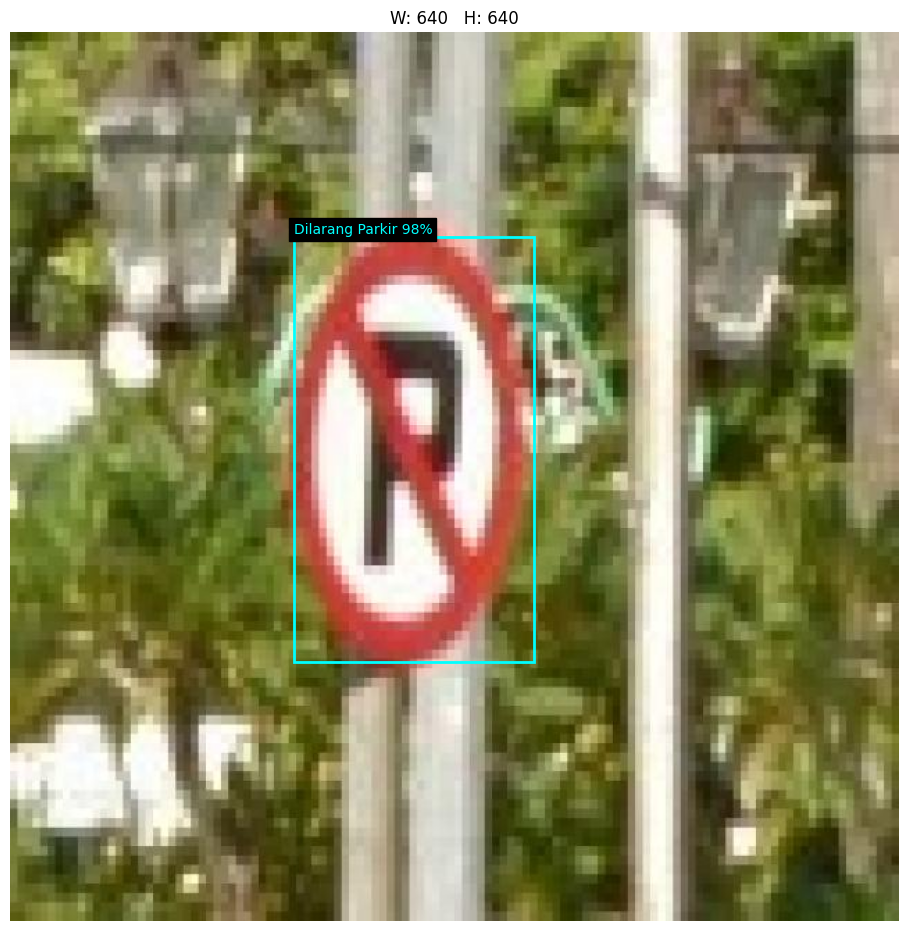

'output_dir/larangan-parkir-12-_jpg.rf.c6df50ee50b5f74a7b08abd213987e9e.jpg'

In [12]:
infer_single_image(model, yolo, "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/test/larangan-parkir-12-_jpg.rf.c6df50ee50b5f74a7b08abd213987e9e.jpg")

In [13]:
# import gradio as gr
# import traceback

# def gradio_infer(image):
#     try:
#         print("Received image:", image)
#         temp_path = "temp.jpg"
#         image.save(temp_path)
#         print("Saved temp image.")

#         result_path = infer_single_image(model, yolo, temp_path)
#         print("Result saved at:", result_path)

#         return Image.open(result_path)
#     except Exception as e:
#         print("Error in gradio_infer:", e)
#         traceback.print_exc()
#         return None


# demo = gr.Interface(
#     fn=gradio_infer,
#     inputs=gr.Image(type="pil", label="Upload an image"),
#     outputs=gr.Image(label="Detection Result"),
#     title="YOLOv5 Traffic Sign Detector",
#     description="Upload an image to detect traffic signs using your trained YOLOv5 model."
# )

# demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()


KeyboardInterrupt: 

visualize.py

In [9]:
import re
from collections import defaultdict

import torch
import matplotlib.pyplot as plt
from matplotlib import patches


def xyxy2xywh(box):
    x1, y1, x2, y2 = box.T
    new_box = torch.stack((x1, y1, x2 - x1, y2 - y1), dim=1)
    return new_box


colors = (
    (0, 1, 1), (1, 0, 1), (1, 1, 0), (1, 0, 0),(0, 1, 0),
    (0.8, 1, 1), (0.5, 0.4, 0.7), (1, 0.6, 0), (1, 0.4, 0.6), (0.4, 0.6, 0.4),
)

def factor(x):
    # RGB color factors
    if x < 10:
        return colors[x]

    i, n = x % 5, x // 5
    base = 0.7 ** n
    extra = 1 - base
    if i < 3:
        f = [base, base, base]
        f[i] = extra
    else:
        f = [extra, extra, extra]
        f[i - 3] = base
    return f

def show_single2(image, target, classes, save=""):
    """
    Show the image, with or without the target
    Arguments:
        image (tensor[3, H, W]): RGB channels, value range: [0.0, 1.0]
        target (dict[tensor]): current support "boxes", "labels", "scores", "masks"
           all tensors should be of the same length, assuming N
           masks: shape=[N, H, W], dtype=torch.float
        classes (tuple): class names
        save (str): path where to save the figure
    """
    image = image.clone()
    if target and "masks" in target:
        masks = target["masks"].unsqueeze(1)
        masks = masks.repeat(1, 3, 1, 1)
        for i, m in enumerate(masks):
            f = torch.tensor(factor(i)).reshape(3, 1, 1).to(image)
            value = f * m
            image += value

    image = image.clamp(0, 1)
    H, W = image.shape[-2:]
    fig = plt.figure(figsize=(W / 72, H / 72))
    ax = fig.add_subplot(111)

    im = image.cpu().numpy()
    ax.imshow(im.transpose(1, 2, 0)) # RGB
    ax.set_title("W: {}   H: {}".format(W, H))
    ax.axis("off")

    if target:
        if "labels" in target:
            if classes is None:
                raise ValueError("'classes' should not be None when 'target' has 'labels'!")
            tags = {l: i for i, l in enumerate(tuple(set(target["labels"].tolist())))}

        index = 0
        if "boxes" in target:
            boxes = target["boxes"]
            boxes = xyxy2xywh(boxes).cpu().detach()
            for i, b in enumerate(boxes):
                if "labels" in target:
                    l = target["labels"][i].item()
                    index = tags[l]
                    txt = classes[l]
                    if "scores" in target:
                        s = target["scores"][i]
                        s = round(s.item() * 100)
                        txt = "{} {}%".format(txt, s)
                    ax.text(
                        b[0], b[1], txt, fontsize=10, color=factor(index),
                        horizontalalignment="left", verticalalignment="bottom",
                        bbox=dict(boxstyle="square", fc="black", lw=1, alpha=1)
                    )


                rect = patches.Rectangle(b[:2], b[2], b[3], linewidth=2, edgecolor=factor(index), facecolor="none")
                ax.add_patch(rect)

    # Remove margins
    plt.gca().xaxis.set_major_locator(plt.NullLocator())
    plt.gca().yaxis.set_major_locator(plt.NullLocator())
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    plt.margins(0, 0)
    plt.draw()

    # Convert Matplotlib figure to PIL Image
    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())  # RGBA image from Agg renderer
    pil_img = Image.fromarray(buf[..., :3])  # Convert to RGB

    if save:
        pil_img.save(save)

    plt.close(fig)
    return pil_img


def parse(txt):
    result = {}
    result["epoch"] = int(re.search(r"^epoch: (\d+)", txt, re.MULTILINE).group(1))
    result["lr_epoch"] = float(re.search(r"lr_epoch: (\d+.\d+)", txt).group(1))
    result["factor"] = float(re.search(r"factor: (\d+.\d+)", txt).group(1))

    outputs = re.findall(r"^(\d+)\s+(\d+.\d+)\s+(\d+.\d+)\s+(\d+.\d+)\n", txt, re.MULTILINE)
    iters, loss_box, loss_obj, loss_cls = zip(*outputs)
    iters = [int(x) for x in iters]
    loss_box = [float(x) for x in loss_box]
    loss_obj = [float(x) for x in loss_obj]
    loss_cls = [float(x) for x in loss_cls]

    result["iters"] = iters[len(iters) // 2]
    result["loss_box"] = sum(loss_box) / len(loss_box)
    result["loss_obj"] = sum(loss_obj) / len(loss_obj)
    result["loss_cls"] = sum(loss_cls) / len(loss_cls)

    result["bbox_AP"] = float(re.search(r"'bbox AP': (\d+.\d+)", txt).group(1))
    return result


def gather(captures):
    results = [parse(txt) for txt in captures]
    results.sort(key=lambda x: x["epoch"])

    info = defaultdict(list)
    for res in results:
        info["epoch"].append(res["epoch"])
        info["lr_epoch"].append(res["lr_epoch"])
        info["factor"].append(res["factor"])
        info["bbox_AP"].append(res["bbox_AP"])

        info["iters"].append(res["iters"])
        info["loss_box"].append(res["loss_box"])
        info["loss_obj"].append(res["loss_obj"])
        info["loss_cls"].append(res["loss_cls"])
    return info


def plot(paths, x="epoch", y=["bbox_AP"], length=None, legend=True):
    if isinstance(paths, str):
        paths = [[paths]]
    else:
        for i, path in enumerate(paths):
            if isinstance(path, str):
                paths[i] = [path]

    if isinstance(y, str):
        y = [y]
    if isinstance(length, int):
        length = [length] * len(paths)

    for i, path in enumerate(paths):
        captures = []
        for p in path:
            with open(p, "r") as f:
                text = f.read()
            captures.extend(re.findall(r"(epoch: \d+\n.*?)}\n", text, re.DOTALL))
        if length is not None:
            captures = captures[:length[i]]

        data = gather(captures)

        x_axis = data[x]
        for k in y:
            label = "{} {}".format(i, k) if len(paths) > 1 else "{}".format(k)
            plt.plot(x_axis, data[k], label=label)
    if legend:
        plt.legend()
    plt.xlabel(x)



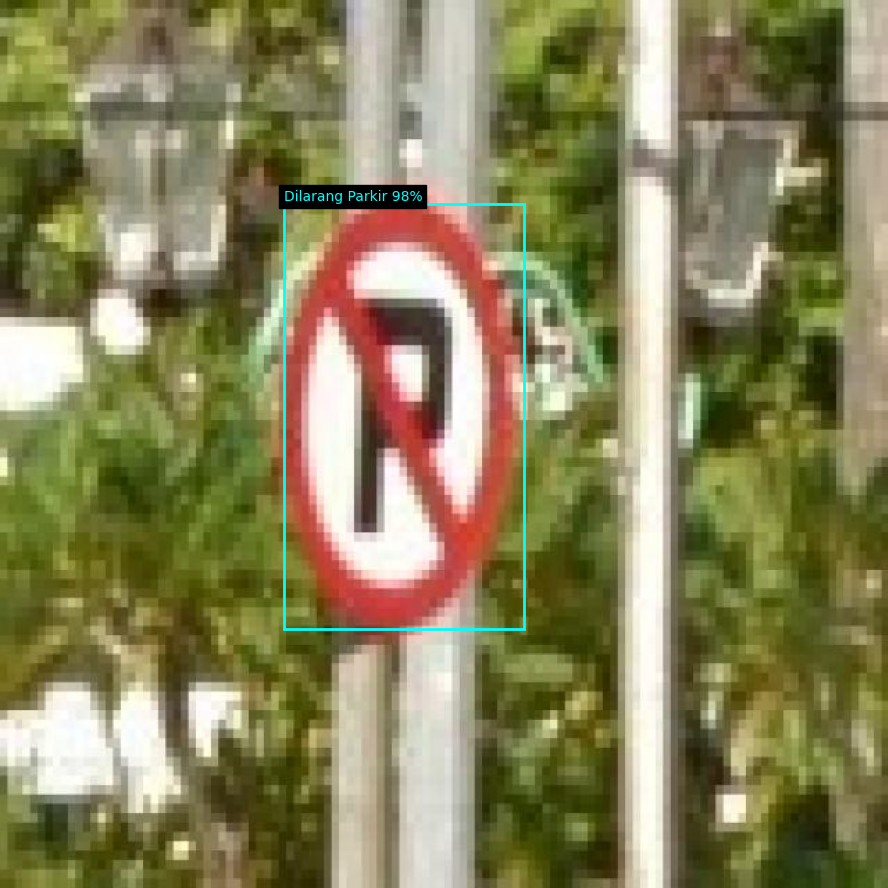

In [16]:
import numpy as np
def infer_single_image2(model, yolo, img_tensor):
    # model.eval()

    img_tensor = preprocess_tensor(img_tensor)
    with torch.no_grad():
        results, losses = model([img_tensor])

    return show_single2(img_tensor, results[0], ds.classes)
    # yolo.show([img_tensor[0]], results, ds.classes, [save_path])
    # return save_path

image_path = "/content/YOLOv5-PyTorch/Traffic-Sign-Indonesia-2/test/larangan-parkir-12-_jpg.rf.c6df50ee50b5f74a7b08abd213987e9e.jpg"
img = Image.open(image_path).convert("RGB")
img_tensor = F.pil_to_tensor(img)
infer_single_image2(model, yolo, img_tensor)

In [17]:
import torch
from PIL import Image

def infer_batch_images(model, yolo, img_tensors, classes, batch_size=8):
    """
    Perform batched inference on multiple image tensors.

    Args:
        model: detection model
        yolo: (optional, not used directly but for consistency)
        img_tensors (List[torch.Tensor]): each [3, H, W]
        classes (tuple): class names
        batch_size (int): max batch size per forward pass

    Returns:
        List[PIL.Image]: list of annotated PIL images
    """
    all_outputs = []

    # Split into manageable batches
    for i in range(0, len(img_tensors), batch_size):
        batch = img_tensors[i:i+batch_size]

        # Ensure preprocessing and stack
        batch = [preprocess_tensor(img) for img in batch]
        batch = torch.stack(batch)  # [N, 3, H, W]

        with torch.no_grad():
            results, losses = model(list(batch))  # list of N tensors

        # Convert each output back to PIL using your visualization
        for j, res in enumerate(results):
            pil_img = show_single2(batch[j], res, classes)
            all_outputs.append(pil_img)

    return all_outputs


In [ ]:
import cv2
import torch
import tempfile
import numpy as np
from PIL import Image
import os
import traceback
import time

def log(message):
  pass

def stream_video_as_chunks(video_path,
                           chunk_seconds: float = 1.0,
                           batch_size: int = 8,
                           device: str = "cuda"):
    """
    Generator that yields 1-second mp4 chunk file paths for Gradio streaming.
    Each chunk is produced by batching frames (batch_size=8) for model inference on GPU.
    """
    try:
        # Ensure device
        dev = torch.device(device if torch.cuda.is_available() and "cuda" in device else "cpu")
        log(f"[INFO] stream_video_as_chunks: device={dev}, video={video_path}, chunk_seconds={chunk_seconds}, batch_size={batch_size}")

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            log("[ERROR] Could not open video.")
            return

        # video properties
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        frames_per_chunk = max(1, int(round(fps * chunk_seconds)))
        log(f"[INFO] fps={fps:.2f}, frames_per_chunk={frames_per_chunk}")

        # we will write chunks at 640x640 (preprocess resizes to that)
        out_w, out_h = 640, 640

        frame_idx = 0
        chunk_idx = 0
        buffer_frames_rgb = []

        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break
            frame_idx += 1

            # Convert to RGB numpy (H,W,3)
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            buffer_frames_rgb.append(frame_rgb)

            # If collected enough frames for a chunk, process it
            if len(buffer_frames_rgb) >= frames_per_chunk:
                chunk_idx += 1
                try:
                    # Preprocess all frames to tensors (CPU) with preprocess_tensor
                    cpu_tensors = []
                    for fr in buffer_frames_rgb:
                        t = torch.from_numpy(fr).permute(2, 0, 1)  # [3,H,W] uint8
                        t = preprocess_tensor(t)                   # should return float [3,640,640]
                        if t is None:
                            raise RuntimeError("preprocess_tensor returned None")
                        cpu_tensors.append(t.cpu())

                    # Run inference in sub-batches of batch_size on device
                    annotated_frames = []  # list of PIL images
                    for i in range(0, len(cpu_tensors), batch_size):
                        group_cpu = cpu_tensors[i:i+batch_size]                # list of CPU tensors
                        group_dev = [g.to(dev) for g in group_cpu]            # move to device
                        with torch.no_grad():
                            results, _ = model(list(group_dev))               # model expects list of tensors

                        # visualize each result using show_single2 (which expects image tensor CPU)
                        for j, res in enumerate(results):
                            # corresponding cpu image:
                            cpu_img_tensor = group_cpu[j]    # float tensor [3,640,640] on CPU
                            pil = show_single2(cpu_img_tensor, res, ds.classes)  # returns PIL
                            annotated_frames.append(pil)

                    # Write annotated_frames into a single mp4 chunk file
                    tmp_out = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
                    out_path = tmp_out.name
                    tmp_out.close()

                    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
                    writer = cv2.VideoWriter(out_path, fourcc, fps, (out_w, out_h))

                    # make sure each PIL is the right size (should be 640x640). Convert to BGR for writer.
                    for pil in annotated_frames:
                        arr = np.array(pil)  # RGB H W 3
                        # If PIL returns other size, resize to (out_w, out_h)
                        if (arr.shape[1], arr.shape[0]) != (out_w, out_h):
                            arr = cv2.resize(arr, (out_w, out_h))
                        bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
                        writer.write(bgr)

                    writer.release()
                    log(f"[INFO] Yielding chunk {chunk_idx} -> {out_path} (frames={len(annotated_frames)})")
                    yield out_path

                except Exception as e:
                    log(f"[ERROR] while processing chunk {chunk_idx}: {e}")
                    traceback.print_exc()
                    # If error, yield a short silent/blank chunk (optional) or continue
                    blank_path = None
                    try:
                        tmp_blank = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
                        blank_path = tmp_blank.name
                        tmp_blank.close()
                        writer = cv2.VideoWriter(blank_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (out_w, out_h))
                        # write one black frame repeated frames_per_chunk times
                        black = np.zeros((out_h, out_w, 3), dtype=np.uint8)
                        for _ in range(max(1, frames_per_chunk)):
                            writer.write(black)
                        writer.release()
                        yield blank_path
                    except Exception:
                        if blank_path and os.path.exists(blank_path):
                            os.remove(blank_path)

                # clear buffer for next chunk
                buffer_frames_rgb = []

        # After loop, if leftover frames exist and you want to emit them as a last chunk:
        if len(buffer_frames_rgb) > 0:
            chunk_idx += 1
            try:
                cpu_tensors = []
                for fr in buffer_frames_rgb:
                    t = torch.from_numpy(fr).permute(2, 0, 1)
                    t = preprocess_tensor(t)
                    if t is None:
                        raise RuntimeError("preprocess_tensor returned None")
                    cpu_tensors.append(t.cpu())

                annotated_frames = []
                for i in range(0, len(cpu_tensors), batch_size):
                    group_cpu = cpu_tensors[i:i+batch_size]
                    group_dev = [g.to(dev) for g in group_cpu]
                    with torch.no_grad():
                        results, _ = model(list(group_dev))
                    for j, res in enumerate(results):
                        pil = show_single2(group_cpu[j], res, ds.classes)
                        annotated_frames.append(pil)

                tmp_out = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
                out_path = tmp_out.name
                tmp_out.close()
                fourcc = cv2.VideoWriter_fourcc(*"mp4v")
                writer = cv2.VideoWriter(out_path, fourcc, fps, (out_w, out_h))
                for pil in annotated_frames:
                    arr = np.array(pil)
                    if (arr.shape[1], arr.shape[0]) != (out_w, out_h):
                        arr = cv2.resize(arr, (out_w, out_h))
                    writer.write(cv2.cvtColor(arr, cv2.COLOR_RGB2BGR))
                writer.release()
                log(f"[INFO] Yielding final chunk {chunk_idx} -> {out_path} (frames={len(annotated_frames)})")
                yield out_path
            except Exception as e:
                log(f"[ERROR] final chunk: {e}")
                traceback.print_exc()

        cap.release()
        log("[DONE] stream_video_as_chunks finished.")

    except Exception as e:
        log(f"[FATAL] stream error: {e}")
        traceback.print_exc()
        return

In [ ]:
import gradio as gr

# Make sure model is on cuda and eval
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

demo = gr.Interface(
    fn=stream_video_as_chunks,
    inputs=gr.Video(label="Upload a video"),
    outputs=gr.Video(streaming=True, autoplay=True, label="Annotated stream"),
    title="YOLO chunked streaming",
)

demo.launch(debug=False)


export

In [18]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.0/683.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 16.7 MB/s eta 0:00:00


In [23]:
dummy_input = torch.randn(1, 3, 640, 640, device=device)

import torchvision.transforms.functional as F

def safe_center_crop(img, size):
    # manually slice tensor instead of rounding float dims
    _, h, w = img.shape
    new_h, new_w = size
    top = (h - new_h) // 2
    left = (w - new_w) // 2
    return img[:, top:top+new_h, left:left+new_w]

F.center_crop = safe_center_crop  # 🔥 monkey-patch

# now export
torch.onnx.export(model, dummy_input, "model.onnx", opset_version=12, dynamo=False)



You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
Iterating over a tensor might cause the trace to be incorrect. Passing a tensor of different shape won't change the number of iterations executed (and might lead to errors or silently give incorrect results).
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize